## **STIR Option Strategy Framework**


### Option Strategy Selection Framework – STIR Futures
This script implements a quantitative framework to support the selection of option strategies on short-term interest rate futures.

Starting from a qualitative market view, the code systematically generates and evaluates option structures using payoff-based metrics, numerical sensitivities and simple volatility assumptions.  
Rather than optimizing a single trade, the objective is to compare alternative strategies in a consistent way, highlighting trade-offs across cost, risk, and scenario alignment.

The framework is applied to two cases:
- EURIBOR, focusing on stability and short-volatility strategies,
- SONIA, focusing on a directional “one-cut” scenario and maturity selection.

**Author:** Alessandra Mattei  
**Date:** January 16th, 2026

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

### Market context and assumptions


In [ ]:
# Defined the market context on which the framework will operate.
# EURIBOR (Case 1)
F_eru = 98.11          # current ERU6 future level
target_eru = 98.06     # landing zone center (trader wants max profit if future expires around this zone)
T_eru = 11 / 12        # 11 months to expiry (in years for Black76)
T_eru_short = 10 / 12  # for roll comparison (proxy)

# SONIA (Case 2)
F_sonia = 96.16        # current SONIA Z5 future level
target_sonia = 96.35   # landing zone for one cut by BoE (that implies higher STIR futures level)
T_x5 = 1 / 12          # November expiry 
T_z5 = 2 / 12          # December expiry

r = 0.02  # flat discount rate assumption (neutral reference level)

print("Market inputs loaded")

Market inputs loaded


### Black-76 Option Pricing

In [ ]:
# Created reusable function for the Black-76 model for European options on futures STIR.

def black76_price(F, K, T, sigma, option_type="call", r=r):
    """
    Black-76 price for European options on futures with discount factor DF = exp(-rT).
    F : future price
    K : strike
    T : time to expiry (years)
    sigma : annualized vol
    option_type : 'call' or 'put'
    """
    if T <= 0:
        return max(F - K, 0) if option_type == "call" else max(K - F, 0)

    DF = np.exp(-r * T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return DF * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return DF * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

# Quick test to verify the function works
test_price = black76_price(
    F=98.11,
    K=98.06,
    T=11/12,
    sigma=0.20,
    option_type="put"
)
print("Test option price:", round(test_price, 4)) 

Test option price: 7.321


### Implied Volatility Proxy

In [ ]:
# Created an implied volatility function since vol surfaces are not provided.
# It introduces skew and local distorsion 

def implied_vol(K, K_atm, vol_atm=0.20, skew=-0.5, special_strike=None, vol_discount=0.03):
    """
    Simple implied vol function with linear skew and optional local distortion.

    - vol_atm = 20% is chosen to ensure realistic option prices and comparable risk profiles across strategies.
    - skew = -0.5 introduces a downward sloping skew, reflecting the typical shape observed in EURIBOR options 
      where downside strikes trade at higher implied volatility due to asymmetric risk and hedging demand.
    - special_strike allows to impose a local volatility distortion on a specific strike, to mimic market distortion.
    - vol_discount = 0.03 represents a moderate but visible distortion, large enough to affect relative strategy pricing without dominating the model.
    A minimum volatility floor is enforced to avoid numerical instability and
    unrealistic option prices.

    """
    vol = vol_atm + skew * (K - K_atm)
    if special_strike is not None and abs(K - special_strike) < 1e-4:
        vol = max(vol - vol_discount, 0.01)
    return max(vol, 0.01)
    # This handles the case where one specific option is unusually cheap because the market is heavily trading it. 
    # We lower its volatility to reflect this effect and make the model consistent with the case.

  # Tested volatility values around EURIBOR target
for k in [97.93, 98.06, 98.18]:
    v = implied_vol(
        K=k,
        K_atm=98.06,
        vol_atm=0.20,
        skew=-0.5,
        special_strike=97.93
    )
    print(f"Strike {k} -> implied vol {round(v, 3)}")


Strike 97.93 -> implied vol 0.235
Strike 98.06 -> implied vol 0.2
Strike 98.18 -> implied vol 0.14


## CASE 1 – EURIBOR: short vol, tight landing zone
### Strike Grid (EURIBOR)

In [ ]:
# Defined the strike interval going from extreme downside to extreme upside scenario with a step of 0.01.
low_eru, high_eru, step_eru = 97.80, 98.30, 0.01 # Extreme downside scenario, extreme upside scenario, 0.01 step.
strikes_eru = np.round(np.arange(low_eru, high_eru + step_eru, step_eru), 2)

print("Number of EURIBOR strikes:", len(strikes_eru))
print("First 5 strikes:", strikes_eru[:5])
print("Last 5 strikes:", strikes_eru[-5:])


Number of EURIBOR strikes: 52
First 5 strikes: [97.8  97.81 97.82 97.83 97.84]
Last 5 strikes: [98.27 98.28 98.29 98.3  98.31]


### Generate Put Fly Universe (EURIBOR)

In [ ]:
# Generated all possible put flies close to the landing zone with realistic widths.

flies = [] # Empty list to store put fly strategies

# Defined 2 variables for the minimum and maximum wing (= distance between central and lateral strikes).
min_wing, max_wing = 0.05, 0.30 # 0.05 = very tight fly (more risk, more concentrated payoff), 0.30 = very wide fly (less risk, larger payoff).

# Created a for cycle to iterate over all possible central strikes (K2) within 15bps of the target EURIBOR level.
for K2 in strikes_eru:
    # Skip strikes that are too far from the target landing zone
    if abs(K2 - target_eru) > 0.15:
        continue
       
        # Then, another for cycle iterates over all possible wing spans (from min_wing to max_wing with 1bp step).
    for wing in np.round(np.arange(min_wing, max_wing + 0.01, 0.01), 2):
        K1 = np.round(K2 - wing, 2)
        K3 = np.round(K2 + wing, 2)

        if K1 < low_eru or K3 > high_eru:
            continue

        flies.append({"type": "put_fly", "K1": K1, "K2": K2, "K3": K3})

print("Generated EURIBOR put flies:", len(flies))
print("Example flies:", flies[:5])


Generated EURIBOR put flies: 403
Example flies: [{'type': 'put_fly', 'K1': np.float64(97.87), 'K2': np.float64(97.92), 'K3': np.float64(97.97)}, {'type': 'put_fly', 'K1': np.float64(97.86), 'K2': np.float64(97.92), 'K3': np.float64(97.98)}, {'type': 'put_fly', 'K1': np.float64(97.85), 'K2': np.float64(97.92), 'K3': np.float64(97.99)}, {'type': 'put_fly', 'K1': np.float64(97.84), 'K2': np.float64(97.92), 'K3': np.float64(98.0)}, {'type': 'put_fly', 'K1': np.float64(97.83), 'K2': np.float64(97.92), 'K3': np.float64(98.01)}]


### Payoff and Pricing (Put Fly)

In [ ]:
# Defined a payoff function for the put fly strategy with the future price at expiry F_T and teh dictionary strat containing the strikes.
# It calculates the payoff in F_T.

def payoff_put_fly(F_T, strat):
    K1, K2, K3 = strat["K1"], strat["K2"], strat["K3"]
    
    # long K1 put, short 2 K2 puts, long K3 put
    return max(K1 - F_T, 0) - 2 * max(K2 - F_T, 0) + max(K3 - F_T, 0)

# Defined a pricing function for the put fly strategy using Black-76 and the implied vol function.
# It calculates the price of a put fly strategy by pricing each leg separately and combining them.

def price_put_fly(F, strat, T):
    K1, K2, K3 = strat["K1"], strat["K2"], strat["K3"]

    # Calculated volatilities for each leg.
    vol1 = implied_vol(K1, K_atm=target_eru, vol_atm=0.20, skew=-0.5, special_strike=97.93)
    vol2 = implied_vol(K2, K_atm=target_eru, vol_atm=0.20, skew=-0.5, special_strike=97.93)
    vol3 = implied_vol(K3, K_atm=target_eru, vol_atm=0.20, skew=-0.5, special_strike=97.93)

    # Calculated price of each option.
    p1 = black76_price(F, K1, T, vol1, "put")
    p2 = black76_price(F, K2, T, vol2, "put")
    p3 = black76_price(F, K3, T, vol3, "put")

    # Total price of the put fly strategy.
    return p1 - 2 * p2 + p3



### Metrics Computation (EURIBOR) - PnL + Theta + Roll

In [ ]:
# Created a list of possible prices at expiry from low_eru to high_eru with a step of 0.005.
# It simulates all the possible final scenarios of the future.

F_grid_eru = np.arange(low_eru, high_eru, 0.005)
profit_threshold = 0.125  # 12.5 ticks (from the track)
dt = 1 / 52  # 1 week (in years)

# Created an empty list to store results for each put fly strategy.
results_eru = []

# Defined a for cycle to iterate each fly calculating entry cost, PnL, theta proxy and roll favourability proxy.
for strat in flies:
    # Entry cost.
    entry_cost = price_put_fly(F_eru, strat, T_eru)

    # Max profit/loss and gain around the target.
    payoffs = np.array([payoff_put_fly(F_T, strat) for F_T in F_grid_eru])
    pnls = payoffs - entry_cost  # PnL

    # Theta proxy (1 week, same spot): how much do I gain from time decay in 1 week?
    V_now = price_put_fly(F_eru, strat, T_eru)
    V_1w = price_put_fly(F_eru, strat, max(T_eru - dt, 1e-6))
    theta_1w = V_now - V_1w  # positive means you earn from time decay

    # Roll favourability proxy: it prices the same strategy on a shorter expiry. Its value should be higher.
    V_short = price_put_fly(F_eru, strat, T_eru_short)
    roll_value = V_short - V_now  # if difference between now vs shorter strategy ispositive => favourable roll

    # Created a dictionary with all the metrics.
    results_eru.append({
        "K1": strat["K1"],
        "K2": strat["K2"],
        "K3": strat["K3"],
        "entry_cost": entry_cost,
        "max_profit": pnls.max(),
        "max_loss": pnls.min(),
        "pnl_at_target": payoff_put_fly(target_eru, strat) - entry_cost,
        "profit_zone_width": np.sum(pnls >= profit_threshold) * 0.005,
        "theta_1w": theta_1w,
        "roll_value": roll_value
    })

# Results list converted into a DataFrame.
df_eru = pd.DataFrame(results_eru)

### Filtering and Scoring (EURIBOR)

In [ ]:

# Filtered out non-viable strategies based on criteria.
df_eru_filt = df_eru.copy()
df_eru_filt = df_eru_filt[df_eru_filt["max_loss"] > -0.5]        # bounded loss filter: max loss less than 50 ticks
df_eru_filt = df_eru_filt[df_eru_filt["pnl_at_target"] >= 0]     # keeps only strategies that make money at target

# Rankings by single criteria
rank_cheapest_eru = df_eru_filt.sort_values("entry_cost").head(10)                          # cheapest strategies
rank_widest_eru = df_eru_filt.sort_values("profit_zone_width", ascending=False).head(10)    # widest profit zone (decreasing): which strategy earns on a wider range?
rank_maxprofit_eru = df_eru_filt.sort_values("max_profit", ascending=False).head(10)        # maximum profit (decreasing)

print("\nEURIBOR - Top 5 cheapest:")
print(rank_cheapest_eru.head(5))

print("\nEURIBOR - Top 5 widest profit zone:")
print(rank_widest_eru.head(5))

print("\nEURIBOR - Top 5 max profit:")
print(rank_maxprofit_eru.head(5))

# Defined a score for each strategy combining metrics with weights choosen by the trader.
# It reflects the trader's preferences on low entry cost, profit at target, profit zone width, theta positive and favorable roll, penalizing risk.

df_eru_score = df_eru_filt.copy()
df_eru_score["score"] = (
    - df_eru_score["entry_cost"]
    + 2.0 * df_eru_score["pnl_at_target"]
    + 1.5 * df_eru_score["profit_zone_width"]
    + 1.0 * df_eru_score["theta_1w"]
    + 0.5 * df_eru_score["roll_value"]
    - 0.2 * abs(df_eru_score["max_loss"])
)

# Sorted by score descending to get the best strategies on top.
df_eru_score = df_eru_score.sort_values("score", ascending=False)

print("\nEURIBOR - Top 5 by score:")
print(df_eru_score.head(5))

top_eru = df_eru_score.iloc[0]
print("\nSelected top EURIBOR strategy:\n", top_eru)




EURIBOR - Top 5 cheapest:
        K1     K2     K3  entry_cost  max_profit  max_loss  pnl_at_target  \
306  97.93  98.11  98.29   -1.111781    1.291781  1.111781       1.241781   
289  97.93  98.10  98.27   -1.110376    1.280376  1.110376       1.240376   
271  97.93  98.09  98.25   -1.108958    1.268958  1.108958       1.238958   
252  97.93  98.08  98.23   -1.107547    1.257547  1.107547       1.237547   
232  97.93  98.07  98.21   -1.106161    1.246161  1.106161       1.236161   

     profit_zone_width  theta_1w  roll_value  
306                0.5 -0.011406    0.050421  
289                0.5 -0.011367    0.050250  
271                0.5 -0.011328    0.050084  
252                0.5 -0.011291    0.049924  
232                0.5 -0.011255    0.049769  

EURIBOR - Top 5 widest profit zone:
        K1     K2     K3  entry_cost  max_profit  max_loss  pnl_at_target  \
306  97.93  98.11  98.29   -1.111781    1.291781  1.111781       1.241781   
232  97.93  98.07  98.21   -1.106161 

### Payoff Diagram (EURIBOR) - PnL at Expiry

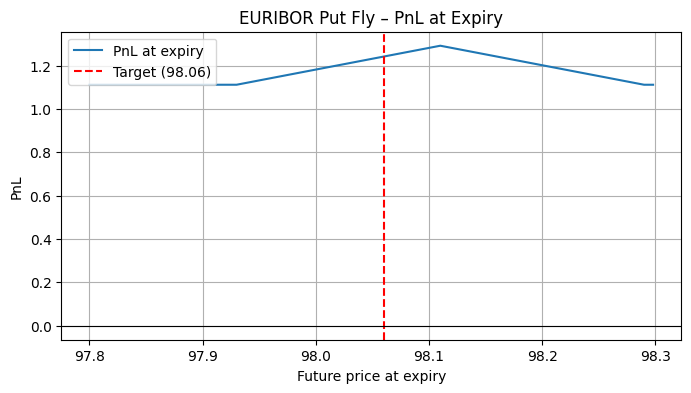

'\nThe PnL profile peaks around the target and remains positive over a relatively wide range, \nshowing that the strategy is robust and well aligned with a short-volatility, stability-driven view.\n'

In [ ]:
# Created a grid of possible future final prices of the futures.
F_plot = np.arange(low_eru, high_eru, 0.002)

# List comprehension: for every F_T, it calculates payoff at expiry of the best strategy and it subtratcts entry cost.
pnl_plot = [
    payoff_put_fly(F_T, {"K1": top_eru["K1"], "K2": top_eru["K2"], "K3": top_eru["K3"]})
    - top_eru["entry_cost"]
    for F_T in F_plot
]

# Plotted the PnL at expiry diagram for the best strategy.
plt.figure(figsize=(8, 4))
plt.plot(F_plot, pnl_plot, label="PnL at expiry")
plt.axvline(target_eru, color="red", linestyle="--", label=f"Target ({target_eru})")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("EURIBOR Put Fly – PnL at Expiry")
plt.xlabel("Future price at expiry")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.show()

"""
The PnL line peaks around the target and remains positive over a wide range,
showing that the strategy is robust and aligned with a short-volatility and stability view.
"""

## CASE 2 – SONIA: directional view, long delta and gamma
### SONIA Market Setup (CASE 2)

In [ ]:
# Recall market setup for SONIA case.

F_sonia = 96.16
target_sonia = 96.35

T_x5 = 1 / 12   # November expiry
T_z5 = 2 / 12   # December expiry

print("SONIA market setup loaded")


SONIA market setup loaded


### Strike Grid (SONIA)

In [ ]:
# Definition of strike intervals (lower price, higher price) and step length

low_sonia, high_sonia, step_sonia = 96.00, 96.70, 0.01
strikes_sonia = np.round(np.arange(low_sonia, high_sonia + step_sonia, step_sonia), 2)
print("\nNumber of SONIA strikes:", len(strikes_sonia))
print("First 5:", strikes_sonia[:5])
print("Last 5:", strikes_sonia[-5:])


Number of SONIA strikes: 72
First 5: [96.   96.01 96.02 96.03 96.04]
Last 5: [96.67 96.68 96.69 96.7  96.71]


### Generate Strike Grid (SONIA)

In [ ]:
# Generated call spreads and call flies around the current level and the target, filtering out unrealistic strikes

call_spreads = []
call_flies = []

# This loop creates a call spreads by selecting lower strike (K1) near current future price
# and higher strike (K2) above K1. 
for K1 in strikes_sonia:
    if K1 < F_sonia - 0.10 or K1 > F_sonia + 0.20:
        continue
    for K2 in strikes_sonia:
        if K2 <= K1:
            continue
        width = K2 - K1
        if 0.05 <= width <= 0.40:
            call_spreads.append({"type": "call_spread", "K1": K1, "K2": K2})
            
# This loop creates call flies by fixing central strike (K2) close to target
# and symmetrically placing 2 wings (K1, K3) at varying distances.
for K2 in strikes_sonia:
    if abs(K2 - target_sonia) > 0.15:
        continue
    for wing in np.arange(0.05, 0.31, 0.01):
        K1 = np.round(K2 - wing, 2)
        K3 = np.round(K2 + wing, 2)
        if K1 >= low_sonia and K3 <= high_sonia:
            call_flies.append({"type": "call_fly", "K1": K1, "K2": K2, "K3": K3})

print("Generated call spreads:", len(call_spreads))
print("Generated call flies:", len(call_flies))


Generated call spreads: 1062
Generated call flies: 680


### Vol Proxy Parameters

In [ ]:
# SONIA specific implied volatility function

def sonia_vol(K):
    return implied_vol(K, K_atm=target_sonia, vol_atm=0.20, skew=-0.3, special_strike=None)

"""
Parameters are different from EURIBOR:
- skew = -0.3 less negative than EURIBOR (-0.5) because SONIA is less prone to large downside moves and because of its directional view.
- special_strike = None since no specific market distortion is assumed in SONIA options.
"""

# quick test
for k in [96.16, 96.35, 96.55]:
    print(k, "->", round(sonia_vol(k), 3))


96.16 -> 0.257
96.35 -> 0.2
96.55 -> 0.14


### Pricing and Payoffs (SONIA)

In [ ]:
# Defined a function that gives the Black76 price of a call spread.
def price_call_spread(F, strat, T):
    c1 = black76_price(F, strat["K1"], T, sonia_vol(strat["K1"]), "call") # long leg (price of the long call with low strike K1)
    c2 = black76_price(F, strat["K2"], T, sonia_vol(strat["K2"]), "call") # short leg (price of the short call with high strike K2)
    return c1 - c2                                                        # Net price of the call spread.

# Defined a function that gives the Black76 price of a call fly.
def price_call_fly(F, strat, T):
    c1 = black76_price(F, strat["K1"], T, sonia_vol(strat["K1"]), "call") # long K1 call
    c2 = black76_price(F, strat["K2"], T, sonia_vol(strat["K2"]), "call") # short 2 K2 calls
    c3 = black76_price(F, strat["K3"], T, sonia_vol(strat["K3"]), "call") # long K3 call
    return c1 - 2*c2 + c3                                                 # Net price of the call fly.

# Defined payoff functions for call spread.
def payoff_call_spread(F_T, strat):
    return max(F_T - strat["K1"], 0) - max(F_T - strat["K2"], 0)  # Gain if future > K1; loss if future > K2.

# Defined payoff function for call fly.
def payoff_call_fly(F_T, strat):
    return max(F_T - strat["K1"], 0) - 2*max(F_T - strat["K2"], 0) + max(F_T - strat["K3"], 0) # Gain if future expires close to K2; loss if far.


### Numerical Delta and Gamma

In [ ]:
# Created a function that numerically calculates delta and gamma.

def numerical_delta_gamma(price_func, F, strat, T, eps=0.01):
    V_up = price_func(F + eps, strat, T) # Value of the strategy if future price goes up by eps (= small price move)
    V_dn = price_func(F - eps, strat, T) # Value of the strategy if future price goes down by eps
    V_0  = price_func(F, strat, T)       # Value of the strategy at current future price
    delta = (V_up - V_dn) / (2 * eps)
    gamma = (V_up - 2*V_0 + V_dn) / (eps**2)
    return delta, gamma


### Metrics Computation (SONIA) - PnL + Cost-normalized Dynamics

In [ ]:
# Grid of possible future final prices of the SONIA futures with a step of 0.005.
F_grid_sonia = np.arange(low_sonia, high_sonia, 0.005)

# Created a function to compute metrics for SONIA strategies at given expiry T and label.
def compute_sonia_metrics(T, label):
    rows = []

    # The for cycle values each call spread based on metrics like entry cost, payoffs, PnL, delta and gamma efficiency and theta.
    for strat in call_spreads:
        entry_cost = price_call_spread(F_sonia, strat, T)
        payoffs = np.array([payoff_call_spread(F_T, strat) for F_T in F_grid_sonia])
        pnls = payoffs - entry_cost  # PnL

        delta, gamma = numerical_delta_gamma(price_call_spread, F_sonia, strat, T)

        # Normalize dynamic exposure by absolute entry cost (efficiency reasons, to measure how much exposure you get per unit of cost)
        denom = max(abs(entry_cost), 1e-6)
        delta_eff = delta / denom
        gamma_eff = gamma / denom

        # theta cost over 1 week (same spot)
        V0 = price_call_spread(F_sonia, strat, T)
        V1 = price_call_spread(F_sonia, strat, max(T - dt, 1e-6))
        theta_1w = V0 - V1

        rows.append({
            "expiry": label,
            "type": "call_spread",
            "K1": strat["K1"],
            "K2": strat["K2"],
            "K3": np.nan,
            "entry_cost": entry_cost,
            "max_profit": pnls.max(),
            "max_loss": pnls.min(),
            "pnl_at_target": payoff_call_spread(target_sonia, strat) - entry_cost,
            "delta_eff": delta_eff,
            "gamma_eff": gamma_eff,
            "theta_1w": theta_1w
        })

    # The for cycle values each call fly based on metrics like entry cost, payoffs, PnL, delta and gamma efficiency and theta.
    for strat in call_flies:
        entry_cost = price_call_fly(F_sonia, strat, T)
        payoffs = np.array([payoff_call_fly(F_T, strat) for F_T in F_grid_sonia])
        pnls = payoffs - entry_cost  #  PnL

        delta, gamma = numerical_delta_gamma(price_call_fly, F_sonia, strat, T)

        denom = max(abs(entry_cost), 1e-6)
        delta_eff = delta / denom
        gamma_eff = gamma / denom

        V0 = price_call_fly(F_sonia, strat, T)
        V1 = price_call_fly(F_sonia, strat, max(T - dt, 1e-6))
        theta_1w = V0 - V1

        rows.append({
            "expiry": label,
            "type": "call_fly",
            "K1": strat["K1"],
            "K2": strat["K2"],
            "K3": strat["K3"],
            "entry_cost": entry_cost,
            "max_profit": pnls.max(),
            "max_loss": pnls.min(),
            "pnl_at_target": payoff_call_fly(target_sonia, strat) - entry_cost,
            "delta_eff": delta_eff,
            "gamma_eff": gamma_eff,
            "theta_1w": theta_1w
        })

    return pd.DataFrame(rows)

# Computed metrics for SONIA strategies at both expiries to choose the best one.
df_x5 = compute_sonia_metrics(T_x5, "X5")
df_z5 = compute_sonia_metrics(T_z5, "Z5")


### Roll cost: match same structures across expiries


In [ ]:
# Defined a function that build a key which identifies the same strategy structure independently from expiry to compare X5 and Z5.
def build_key(df):
    return (
        df["type"].astype(str)
        + "_" + df["K1"].astype(str)
        + "_" + df["K2"].astype(str)
        + "_" + df["K3"].astype(str)
    )

df_x5 = df_x5.copy()
df_z5 = df_z5.copy()
df_x5["key"] = build_key(df_x5)
df_z5["key"] = build_key(df_z5)
# Now it is possible to allign same strategies across expiries to compute roll costs.

# Merged X5 and Z5 dataframes on the key to compare same strategies.
roll_df = df_x5.merge(
    df_z5[["key", "entry_cost", "theta_1w", "delta_eff", "gamma_eff", "pnl_at_target"]],
    on="key",
    suffixes=("_x5", "_z5")
)

# Calculated how much does it cost to roll each strategy from X5 to Z5.
# if positive => rolling costs money; if negative => rolling gains money.
roll_df["roll_cost_x5_to_z5"] = roll_df["entry_cost_z5"] - roll_df["entry_cost_x5"]
roll_df["roll_cost"] = roll_df["entry_cost_z5"] - roll_df["entry_cost_x5"]




### Score for SONIA case (X5 vs Z5)

In [ ]:
# RANKING SONIA STRATEGIES
df_rank = roll_df.copy()

# Filter: it keeps only strategies that make money at target in X5 expiry.
df_rank = df_rank[df_rank["pnl_at_target_x5"] > 0]

# Score (weights = trader-defined, different from EURIBOR due to directional and convexity)
df_rank["score"] = (
    + 2.0 * df_rank["delta_eff_x5"]              # reward high delta efficiency (directional)
    + 1.5 * df_rank["gamma_eff_x5"]              # reward high gamma efficiency (convexity)
    + 2.0 * df_rank["pnl_at_target_x5"]          # reward profit at target   
    - 1.0 * df_rank["entry_cost_x5"]             # penalize high entry cost
    - 1.0 * df_rank["theta_1w_x5"]               # penalize negative theta (time decay)
    - 0.5 * abs(df_rank["roll_cost_x5_to_z5"])   # penalize rolling costs
    + 0.5 * df_rank["pnl_at_target_z5"]          # reward long expiry scenario payoff
)

# Sort by score descending
df_rank = df_rank.sort_values("score", ascending=False)

print("\nSONIA - Top 10 strategies (ranked):")
print(df_rank.head(10)[[
    "key",
    "entry_cost_x5", "entry_cost_z5",
    "theta_1w_x5", "theta_1w_z5",
    "roll_cost_x5_to_z5",
    "delta_eff_x5", "gamma_eff_x5",
    "pnl_at_target_x5", "pnl_at_target_z5",
    "score"
]])

# SELECT TOP STRATEGY (SONIA)
top_sonia = df_rank.iloc[0]
print("\nSelected top SONIA strategy:\n", top_sonia)



SONIA - Top 10 strategies (ranked):
                             key  entry_cost_x5  entry_cost_z5  theta_1w_x5  \
1422  call_fly_96.05_96.35_96.65       0.009821       0.003965    -0.002360   
1421  call_fly_96.06_96.35_96.64       0.008976       0.003562    -0.002178   
1448  call_fly_96.06_96.36_96.66       0.010547       0.004492    -0.002458   
1396  call_fly_96.04_96.34_96.64       0.009144       0.003474    -0.002269   
1420  call_fly_96.07_96.35_96.63       0.008192       0.003196    -0.002007   
1447  call_fly_96.07_96.36_96.65       0.009636       0.004041    -0.002267   
1474  call_fly_96.07_96.37_96.67       0.011329       0.005058    -0.002563   
1395  call_fly_96.05_96.34_96.63       0.008361       0.003116    -0.002096   
1446  call_fly_96.08_96.36_96.64       0.008792       0.003631    -0.002087   
1370  call_fly_96.03_96.33_96.63       0.008514       0.003016    -0.002185   

      theta_1w_z5  roll_cost_x5_to_z5  delta_eff_x5  gamma_eff_x5  \
1422    -0.001031       

### SONIA – Strategy Value Today: X5 vs Z5

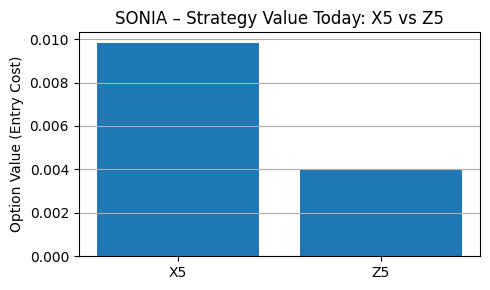

In [ ]:
# Extracted values from selected strategy
labels = ["X5", "Z5"]
values = [
    top_sonia["entry_cost_x5"],
    top_sonia["entry_cost_z5"]
]

# This graph visually confronts the two expiries
plt.figure(figsize=(5, 3))
plt.bar(labels, values)
plt.title("SONIA – Strategy Value Today: X5 vs Z5")
plt.ylabel("Option Value (Entry Cost)")
plt.grid(axis="y")

plt.tight_layout()
plt.show()


# X5 shows a higher value than Z5, reflecting stronger exposure to the expected near-term SONIA rate cut.
# The shorter maturity captures the anticipated market reaction more effectively, making it the preferred choice for the trader's strategy.

### Payoff Diagram (SONIA – PnL at Expiry, X5)


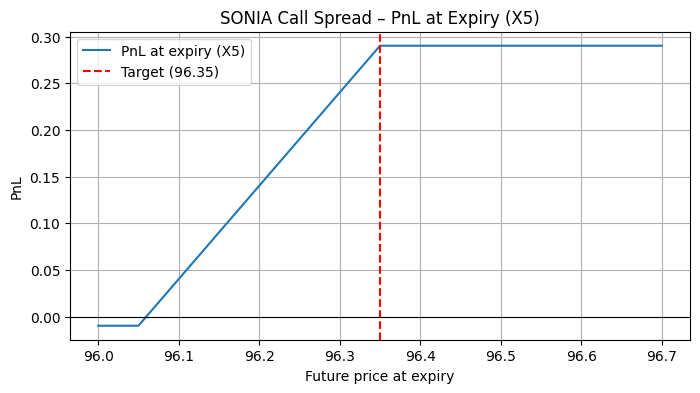

In [ ]:
# List of possible future final prices of the SONIA futures for plotting.
F_plot = np.arange(low_sonia, high_sonia, 0.002)

# Reconstructed strikes from key
parts = top_sonia["key"].split("_")
stype = parts[0]
K1 = float(parts[2])
K2 = float(parts[3])
K3 = float(parts[4])

# Here, the model is allowed to plot either a call fly or a call spread based on the selected strategy type.
if stype == "call_fly":
    strat = {"K1": K1, "K2": K2, "K3": K3}
    pnl_plot = [payoff_call_fly(F_T, strat) - top_sonia["entry_cost_x5"] for F_T in F_plot]
    title_str = "SONIA Call Fly – PnL at Expiry (X5)"
else:
    strat = {"K1": K1, "K2": K2}
    pnl_plot = [payoff_call_spread(F_T, strat) - top_sonia["entry_cost_x5"] for F_T in F_plot]
    title_str = "SONIA Call Spread – PnL at Expiry (X5)"

plt.figure(figsize=(8, 4))
plt.plot(F_plot, pnl_plot, label="PnL at expiry (X5)")
plt.axvline(target_sonia, color="red", linestyle="--", label=f"Target ({target_sonia})")
plt.axhline(0, color="black", linewidth=0.8)
plt.title(title_str)
plt.xlabel("Future price at expiry")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.show()


"""
The graph shows that the call spread generates positive PnL as SONIA futures move towards the target level.
The linear increase in PnL reflects the directional nature of the strategy (you gain as rates rise).
After a certain level, profits stop increasing, so risk stays controlled. Since the target is inside the profit area, the strategy matches the scenario well.
"""